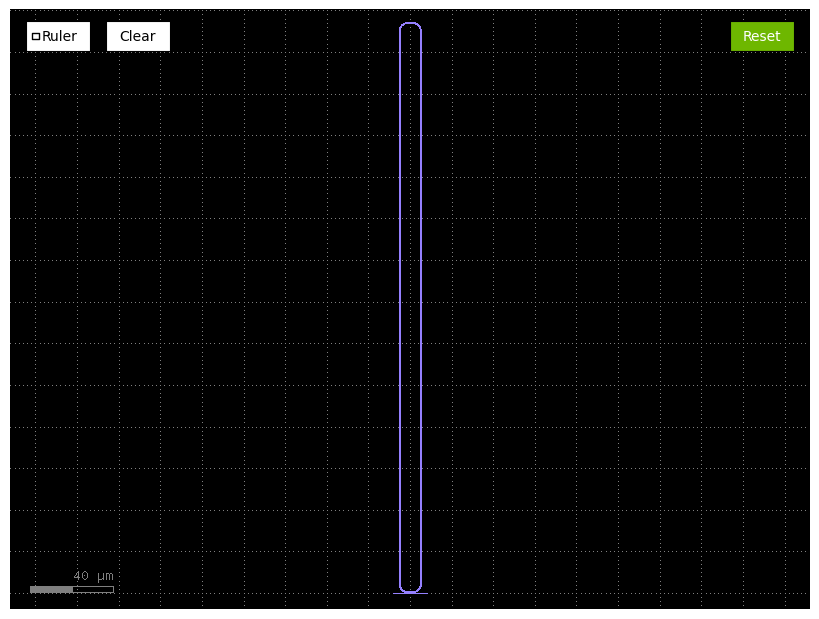

In [3]:
import gdsfactory as gf
import numpy as np
import cspdk.si220.cband
from axiomatic.pic_helpers import plot_circuit
cspdk.si220.cband.activate_pdk()

pdk = gf.get_active_pdk()
c = gf.Component()

def ring_resonator(coupling_length: float, target_fsr: float, center_wvl: float) -> gf.Component:
    bend_radius = 5  # Bend radius in micrometers
    n_eff = 2.38
    n_g = 4.3

    cavity_length_target_fsr = center_wvl**2 / (n_g * target_fsr * 1e-3)

    m = round(n_eff * cavity_length_target_fsr / center_wvl)
    ring_length_target = m * center_wvl / n_eff  # Actual round-trip length for resonance at 1.55 um
    length_arc = 2 * np.pi * bend_radius

    c = gf.Component()

    # Adjust length_y to maintain constant round-trip length
    length_x = coupling_length
    length_y = (ring_length_target - length_arc - 2 * length_x)/2

    ring = c << pdk.get_component(
        'ring_single',
        radius=bend_radius,
        gap=0.2,
        length_x=length_x,
        length_y=length_y
    )
    ring.name = "ring"

    ring.rotate(0).move((0.0, 0.0))

    # Add ports
    c.add_port("in0", port=ring.ports["o1"])
    c.add_port("out0", port=ring.ports["o2"])

    return c


# Example usage and plot
if __name__ == "__main__":
    c = ring_resonator(
        coupling_length = 0.2, 
        target_fsr = 1, 
        center_wvl = 1.55)
    plot_circuit(c)
    